# Recommendation Systems: User-Based & Item-Based Collaborative Filtering


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

print("Name: Mohamed Aashik S \nRoll No: 24BAD072\n")


Name: Mohamed Aashik S 
Roll No: 24BAD072



## SCENARIO 1: USER-BASED COLLABORATIVE FILTERING


In [3]:
ratings = pd.read_csv('Dataset/ratings.csv')
movies = pd.read_csv('Dataset/movies.csv')

print(f"Ratings: {ratings.shape}, Movies: {movies.shape}")
print(ratings.head(10))
print(movies.head(10))
print(f"Rating range: {ratings['rating'].min()}-{ratings['rating'].max()}")

Ratings: (100836, 4), Movies: (9742, 3)
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
5       1       70     3.0  964982400
6       1      101     5.0  964980868
7       1      110     4.0  964982176
8       1      151     5.0  964984041
9       1      157     5.0  964984100
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   
5        6                         Heat (1995)   
6        7                      Sabrina (1995)   
7        8                 Tom and Huck (1995)   
8        9                 Sudden Death (1995)   
9       10                    GoldenEye (1

In [4]:
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print(f"User-Item Matrix: {user_item_matrix.shape}")
print(user_item_matrix.iloc[:5, :5])

User-Item Matrix: (610, 9724)
movieId    1   2    3   4   5
userId                       
1        4.0 NaN  4.0 NaN NaN
2        NaN NaN  NaN NaN NaN
3        NaN NaN  NaN NaN NaN
4        NaN NaN  NaN NaN NaN
5        4.0 NaN  NaN NaN NaN


In [5]:
total_elements = user_item_matrix.size
non_zero = np.count_nonzero(user_item_matrix)
sparsity = 1 - (non_zero / total_elements)

print(f"Sparsity: {sparsity*100:.2f}%")

user_item_filled = user_item_matrix.fillna(0)

Sparsity: 0.00%


In [6]:
user_similarity = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

print(f"User Similarity Matrix: {user_similarity_df.shape}")
print(user_similarity_df[1].sort_values(ascending=False).head(6))  # include self

User Similarity Matrix: (610, 610)
userId
1      1.000000
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64


In [7]:
def get_similar_users(user_id, n=5):
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    return sim_scores.iloc[1:n+1]

def predict_ratings_user_based(user_id, n_neighbors=5):
    similar_users = get_similar_users(user_id, n_neighbors)
    user_ratings = user_item_filled.loc[user_id]
    predicted_ratings = {}
    
    for movie in user_item_filled.columns:
        if user_ratings[movie] == 0:
            weighted_sum = 0
            similarity_sum = 0
            
            for sim_user, sim_score in similar_users.items():
                rating = user_item_filled.loc[sim_user, movie]
                if rating > 0:
                    weighted_sum += sim_score * rating
                    similarity_sum += sim_score
            
            if similarity_sum > 0:
                predicted_ratings[movie] = weighted_sum / similarity_sum
    
    return predicted_ratings

def recommend_movies_user_based(user_id, n=5):
    preds = predict_ratings_user_based(user_id)
    sorted_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)
    top_movies = sorted_preds[:n]
    movie_ids = [movie[0] for movie in top_movies]
    
    return movies[movies['movieId'].isin(movie_ids)]

test_user = 1
recs = recommend_movies_user_based(test_user, 5)
print(recs[['movieId', 'title', 'genres']])

     movieId                                              title  \
449      514                                    Ref, The (1994)   
474      541                                Blade Runner (1982)   
585      720  Wallace & Gromit: The Best of Aardman Animatio...   
602      750  Dr. Strangelove or: How I Learned to Stop Worr...   
659      858                              Godfather, The (1972)   

                         genres  
449                      Comedy  
474      Action|Sci-Fi|Thriller  
585  Adventure|Animation|Comedy  
602                  Comedy|War  
659                 Crime|Drama  


In [8]:
def evaluate_user_based(sample_size=500, n_neighbors=5):
    sample_data = ratings.sample(sample_size, random_state=42)
    actual = []
    predicted = []
    
    for _, row in sample_data.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']
        
        if user in user_item_filled.index and movie in user_item_filled.columns:
            similar_users = get_similar_users(user, n_neighbors)
            
            weighted_sum = 0
            similarity_sum = 0
            
            for sim_user, sim_score in similar_users.items():
                rating = user_item_filled.loc[sim_user, movie]
                if rating > 0:
                    weighted_sum += sim_score * rating
                    similarity_sum += sim_score
            
            if similarity_sum > 0:
                pred = weighted_sum / similarity_sum
                actual.append(true_rating)
                predicted.append(pred)
    
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    
    print(f"User-Based - RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return actual, predicted, rmse, mae

actual_user, predicted_user, rmse_user, mae_user = evaluate_user_based()

User-Based - RMSE: 0.9795, MAE: 0.7464


In [9]:
def analyze_similarity_impact(user_id, n_neighbors_list=[1, 3, 5, 10]):
    for n in n_neighbors_list:
        similar_users = get_similar_users(user_id, n)
        avg_similarity = similar_users.mean()
        preds = predict_ratings_user_based(user_id, n)
        avg_pred_rating = np.mean(list(preds.values())) if preds else 0
        print(f"User {user_id}, N={n}: Similarity={avg_similarity:.4f}, Avg Rating={avg_pred_rating:.2f}, Recs={len(preds)}")

analyze_similarity_impact(1)
analyze_similarity_impact(10)

User 1, N=1: Similarity=0.3574, Avg Rating=3.19, Recs=113
User 1, N=3: Similarity=0.3514, Avg Rating=3.01, Recs=590
User 1, N=5: Similarity=0.3468, Avg Rating=3.13, Recs=997
User 1, N=10: Similarity=0.3380, Avg Rating=3.23, Recs=1679
User 10, N=1: Similarity=0.2883, Avg Rating=3.16, Recs=63
User 10, N=3: Similarity=0.2755, Avg Rating=3.20, Recs=248
User 10, N=5: Similarity=0.2608, Avg Rating=3.27, Recs=948
User 10, N=10: Similarity=0.2391, Avg Rating=3.22, Recs=1782


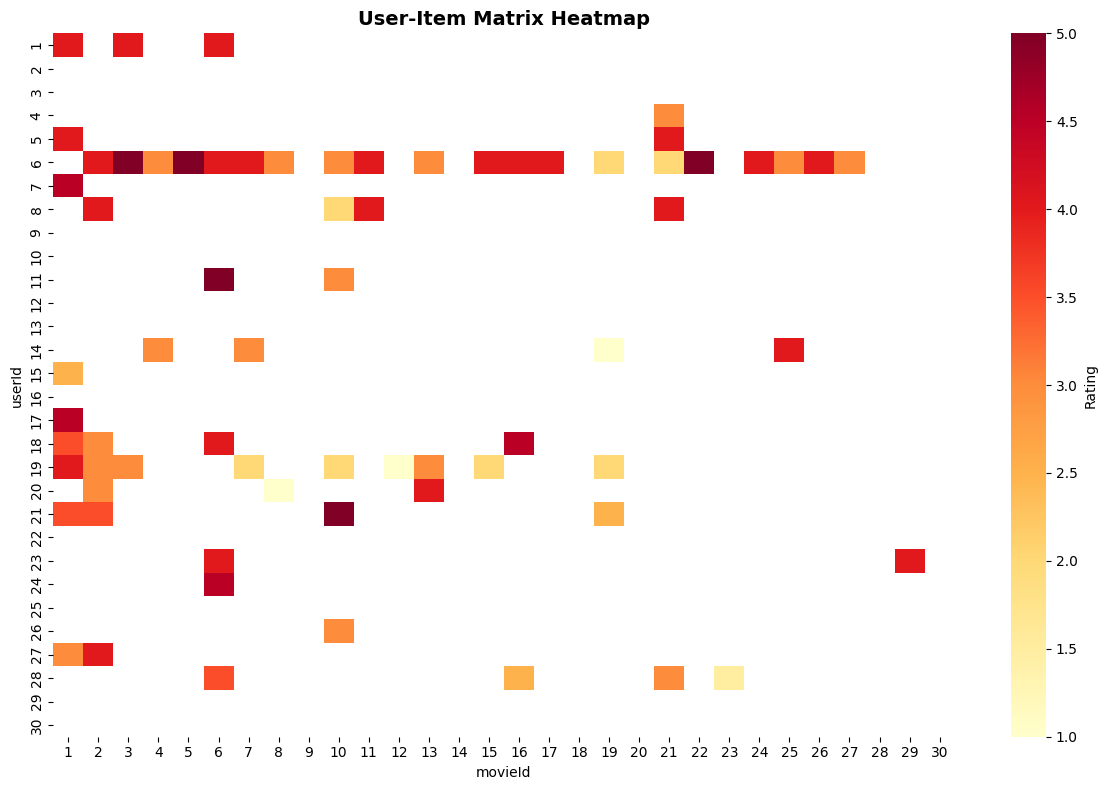

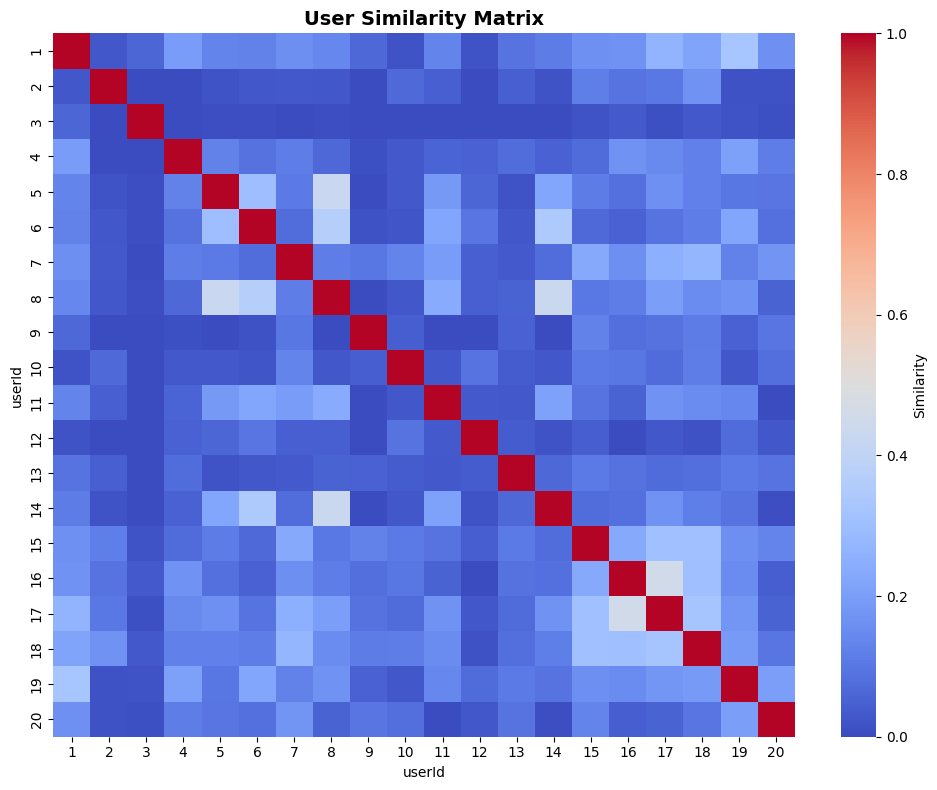

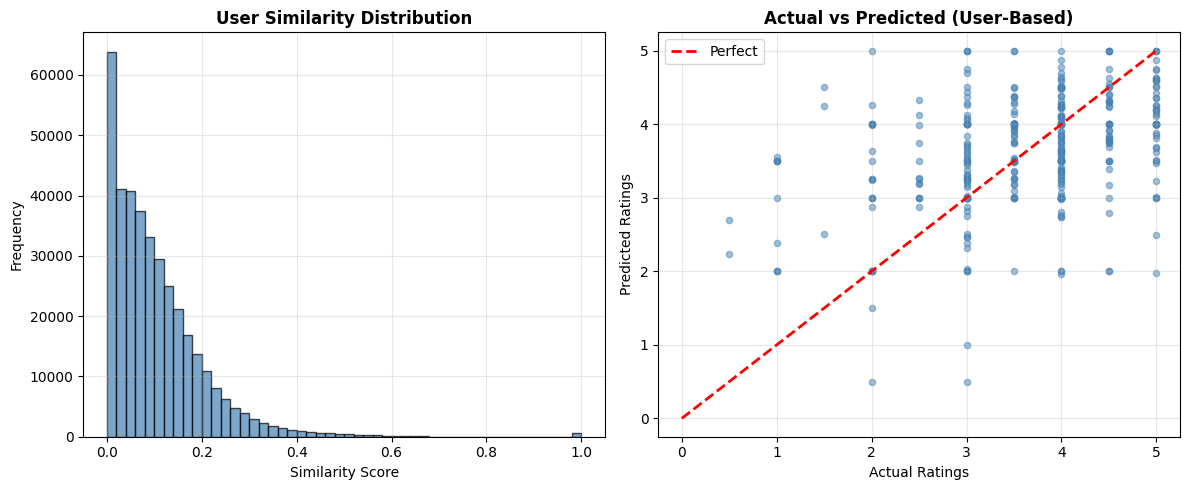

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(user_item_matrix.iloc[:30, :30], cmap='YlOrRd', cbar_kws={'label': 'Rating'})
plt.title('User-Item Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='coolwarm', cbar_kws={'label': 'Similarity'})
plt.title('User Similarity Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
similarity_values = user_similarity_df.values.flatten()
plt.hist(similarity_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('User Similarity Distribution', fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(actual_user, predicted_user, alpha=0.5, s=20, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', lw=2, label='Perfect')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted (User-Based)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## SCENARIO 2: ITEM-BASED COLLABORATIVE FILTERING


In [11]:
item_user_matrix = ratings.pivot_table(
    index='movieId',
    columns='userId',
    values='rating'
)

item_user_filled = item_user_matrix.fillna(0)

print(f"Item-User Matrix: {item_user_filled.shape}")
print(item_user_filled.iloc[:5, :5])

Item-User Matrix: (9724, 610)
userId     1    2    3    4    5
movieId                         
1        4.0  0.0  0.0  0.0  4.0
2        0.0  0.0  0.0  0.0  0.0
3        4.0  0.0  0.0  0.0  0.0
4        0.0  0.0  0.0  0.0  0.0
5        0.0  0.0  0.0  0.0  0.0


In [12]:
item_similarity = cosine_similarity(item_user_filled)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_filled.index,
    columns=item_user_filled.index
)

print(f"Item Similarity Matrix: {item_similarity_df.shape}")

if 1 in item_similarity_df.index:
    similar_to_1 = item_similarity_df[1].sort_values(ascending=False).head(11)
    movie_details = movies[movies['movieId'].isin(similar_to_1.index)]
    print("Similar to Movie 1:")
    print(movie_details[['movieId', 'title']].to_string())

Item Similarity Matrix: (9724, 9724)
Similar to Movie 1:
      movieId                                              title
0           1                                   Toy Story (1995)
224       260          Star Wars: Episode IV - A New Hope (1977)
314       356                                Forrest Gump (1994)
322       364                              Lion King, The (1994)
418       480                               Jurassic Park (1993)
546       648                         Mission: Impossible (1996)
615       780               Independence Day (a.k.a. ID4) (1996)
911      1210  Star Wars: Episode VI - Return of the Jedi (1983)
964      1265                               Groundhog Day (1993)
969      1270                          Back to the Future (1985)
2355     3114                                 Toy Story 2 (1999)


In [13]:
def get_similar_items(movie_id, n=5):
    if movie_id not in item_similarity_df.index:
        return pd.Series()
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    return sim_scores.iloc[1:n+1]

def recommend_items_item_based(user_id, n=5):
    user_ratings = ratings[ratings['userId'] == user_id]
    
    if user_ratings.empty:
        return pd.DataFrame()
    
    scores = {}
    
    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']
        
        similar_items = get_similar_items(movie, 10)
        
        for sim_movie, sim_score in similar_items.items():
            if sim_movie not in user_ratings['movieId'].values:
                scores[sim_movie] = scores.get(sim_movie, 0) + sim_score * rating
    
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_items = [movie_id for movie_id, _ in sorted_scores[:n]]
    
    return movies[movies['movieId'].isin(top_items)]

test_user = 1
user_history = ratings[ratings['userId'] == test_user][['movieId', 'rating']].head()
user_with_titles = user_history.merge(movies, on='movieId')
print(f"User {test_user} rated:")
print(user_with_titles[['movieId', 'title', 'rating']])

item_recs = recommend_items_item_based(test_user, 5)
if not item_recs.empty:
    print("\nItem-Based Recommendations:")
    print(item_recs[['movieId', 'title', 'genres']])

User 1 rated:
   movieId                        title  rating
0        1             Toy Story (1995)     4.0
1        3      Grumpier Old Men (1995)     4.0
2        6                  Heat (1995)     4.0
3       47  Seven (a.k.a. Se7en) (1995)     5.0
4       50   Usual Suspects, The (1995)     5.0

Item-Based Recommendations:
      movieId                              title  \
337       380                   True Lies (1994)   
507       589  Terminator 2: Judgment Day (1991)   
902      1200                      Aliens (1986)   
1550     2087                   Peter Pan (1953)   
2195     2918    Ferris Bueller's Day Off (1986)   

                                        genres  
337   Action|Adventure|Comedy|Romance|Thriller  
507                              Action|Sci-Fi  
902             Action|Adventure|Horror|Sci-Fi  
1550        Animation|Children|Fantasy|Musical  
2195                                    Comedy  


In [14]:
def evaluate_item_based(sample_size=500):
    sample_data = ratings.sample(sample_size, random_state=42)
    actual = []
    predicted = []
    
    for _, row in sample_data.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']
        
        if movie in item_similarity_df.index:
            user_data = ratings[ratings['userId'] == user]
            
            weighted_sum = 0
            similarity_sum = 0
            
            for _, r in user_data.iterrows():
                sim = item_similarity_df.loc[movie, r['movieId']]
                if sim > 0 and r['movieId'] != movie:
                    weighted_sum += sim * r['rating']
                    similarity_sum += sim
            
            if similarity_sum > 0:
                pred = weighted_sum / similarity_sum
                actual.append(true_rating)
                predicted.append(pred)
    
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    
    print(f"Item-Based - RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return actual, predicted, rmse, mae

actual_item, predicted_item, rmse_item, mae_item = evaluate_item_based()

def precision_at_k(user_id, k=5, threshold=4.0):
    recs = recommend_items_item_based(user_id, k)
    
    if recs.empty:
        return 0
    
    rec_movie_ids = recs['movieId'].values
    user_data = ratings[ratings['userId'] == user_id]
    relevant = user_data[user_data['rating'] >= threshold]['movieId'].values
    
    hit = sum([1 for movie in rec_movie_ids if movie in relevant])
    return hit / k

precisions = []
for user in [1, 2, 3, 5, 10]:
    p_at_5 = precision_at_k(user, k=5, threshold=4.0)
    precisions.append(p_at_5)
    print(f"User {user}: Precision@5 = {p_at_5:.4f}")

print(f"Average Precision@5: {np.mean(precisions):.4f}")

Item-Based - RMSE: 0.9466, MAE: 0.7294
User 1: Precision@5 = 0.0000
User 2: Precision@5 = 0.0000
User 3: Precision@5 = 0.0000
User 5: Precision@5 = 0.0000
User 10: Precision@5 = 0.0000
Average Precision@5: 0.0000


In [15]:
comparison_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE'],
    'User-Based': [rmse_user, mae_user],
    'Item-Based': [rmse_item, mae_item]
})

print("Performance Comparison:")
print(comparison_df.to_string(index=False))

print("\nUser-Based Recommendations:")
user_based_recs = recommend_movies_user_based(1, 5)
if not user_based_recs.empty:
    print(user_based_recs[['movieId', 'title']].to_string())

print("\nItem-Based Recommendations:")
item_based_recs = recommend_items_item_based(1, 5)
if not item_based_recs.empty:
    print(item_based_recs[['movieId', 'title']].to_string())

Performance Comparison:
Metric  User-Based  Item-Based
  RMSE    0.979481    0.946631
   MAE    0.746435    0.729448

User-Based Recommendations:
     movieId                                                                        title
449      514                                                              Ref, The (1994)
474      541                                                          Blade Runner (1982)
585      720                       Wallace & Gromit: The Best of Aardman Animation (1996)
602      750  Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
659      858                                                        Godfather, The (1972)

Item-Based Recommendations:
      movieId                              title
337       380                   True Lies (1994)
507       589  Terminator 2: Judgment Day (1991)
902      1200                      Aliens (1986)
1550     2087                   Peter Pan (1953)
2195     2918    Ferris Bueller's Day Of

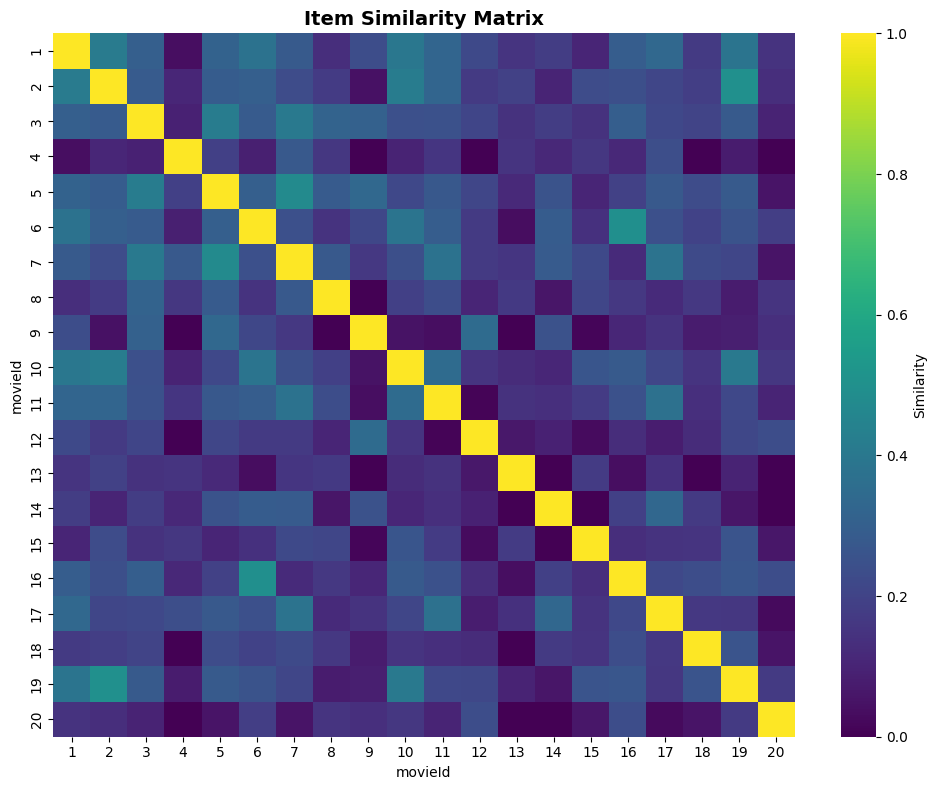

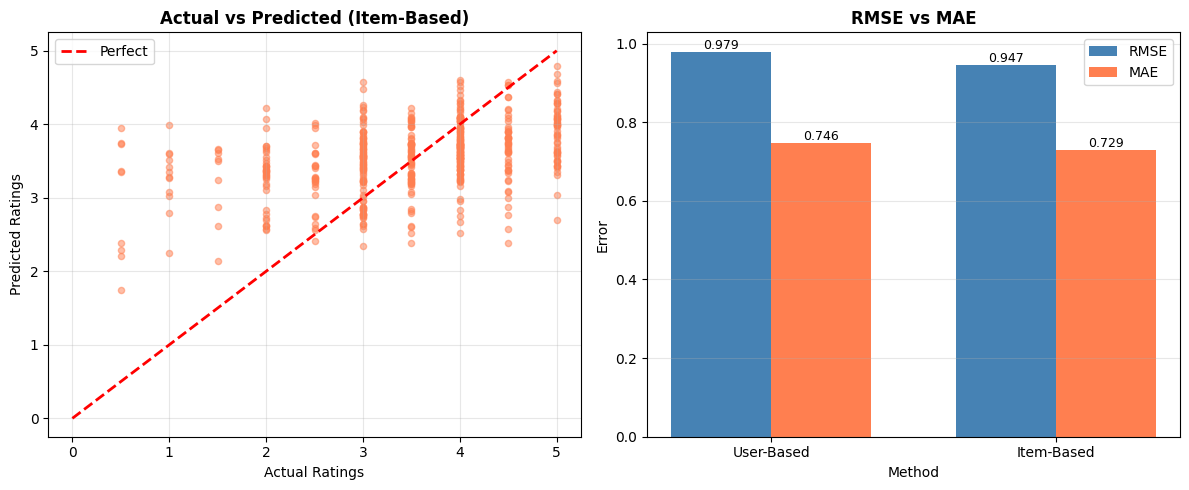

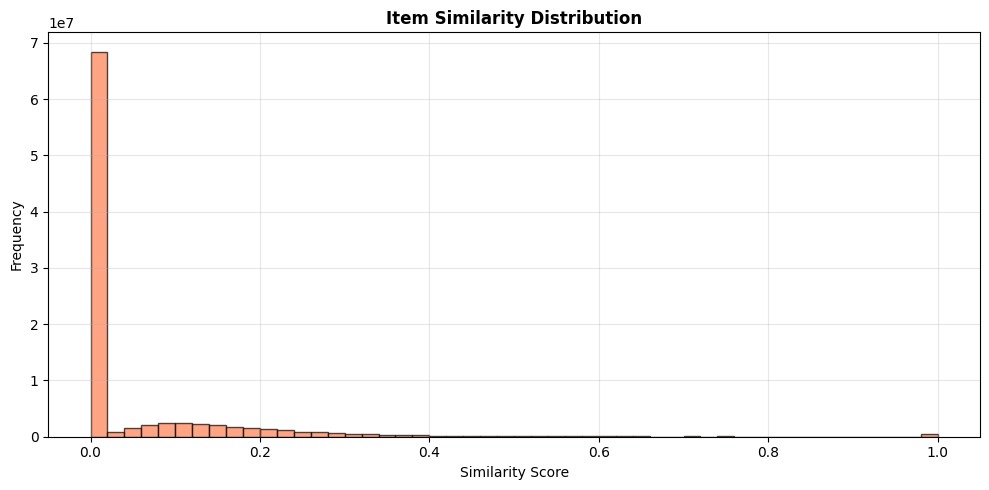

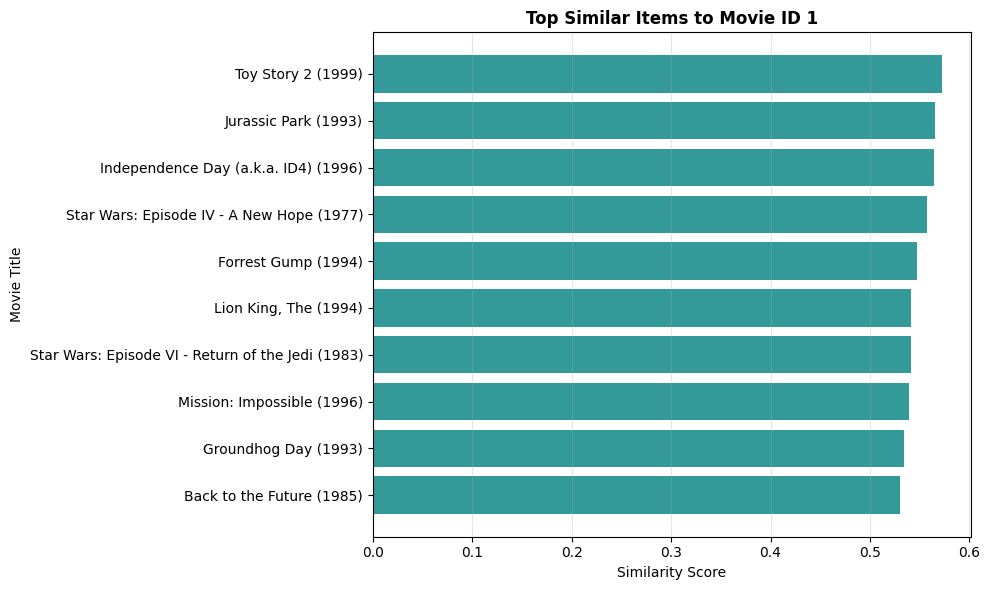

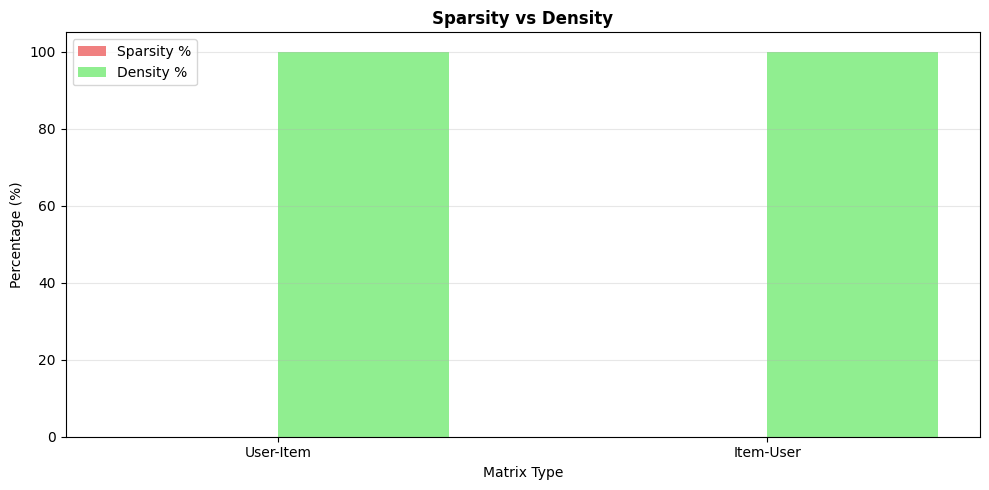

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='viridis', cbar_kws={'label': 'Similarity'})
plt.title('Item Similarity Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(actual_item, predicted_item, alpha=0.5, s=20, color='coral')
plt.plot([0, 5], [0, 5], 'r--', lw=2, label='Perfect')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted (Item-Based)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
methods = ['User-Based', 'Item-Based']
rmse_values = [rmse_user, rmse_item]
mae_values = [mae_user, mae_item]
x = np.arange(len(methods))
width = 0.35

bars1 = plt.bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue')
bars2 = plt.bar(x + width/2, mae_values, width, label='MAE', color='coral')

plt.xlabel('Method')
plt.ylabel('Error')
plt.title('RMSE vs MAE', fontweight='bold')
plt.xticks(x, methods)
plt.legend()
plt.grid(alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
similarity_values = item_similarity_df.values.flatten()
plt.hist(similarity_values, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Item Similarity Distribution', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Top similar items graph for a reference movie
reference_movie_id = 1
if reference_movie_id in item_similarity_df.index:
    top_similar = item_similarity_df[reference_movie_id].sort_values(ascending=False).iloc[1:11]
    top_similar_df = pd.DataFrame({
        'movieId': top_similar.index,
        'similarity': top_similar.values
    }).merge(movies[['movieId', 'title']], on='movieId', how='left')

    plt.figure(figsize=(10, 6))
    plt.barh(top_similar_df['title'], top_similar_df['similarity'], color='teal', alpha=0.8)
    plt.xlabel('Similarity Score')
    plt.ylabel('Movie Title')
    plt.title(f'Top Similar Items to Movie ID {reference_movie_id}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print(f'Movie ID {reference_movie_id} not found in similarity matrix.')

matrices_info = {
    'User-Item': [user_item_matrix.size, np.count_nonzero(user_item_matrix)],
    'Item-User': [item_user_matrix.size, np.count_nonzero(item_user_matrix)]
}

sparsity_vals = [1 - (info[1]/info[0]) for info in matrices_info.values()]
density_vals = [info[1]/info[0] for info in matrices_info.values()]

plt.figure(figsize=(10, 5))
x = np.arange(len(matrices_info))
width = 0.35

plt.bar(x - width/2, [s*100 for s in sparsity_vals], width, label='Sparsity %', color='lightcoral')
plt.bar(x + width/2, [d*100 for d in density_vals], width, label='Density %', color='lightgreen')

plt.xlabel('Matrix Type')
plt.ylabel('Percentage (%)')
plt.title('Sparsity vs Density', fontweight='bold')
plt.xticks(x, matrices_info.keys())
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()